# イベントスタディ: ASOF で発表日を揃えて CAR を出す

定番のイベントスタディは、マーケットモデルの異常リターンと、発表前後の累積異常リターンを
計算します。そのうち1工程がいつまでも厄介です。発表は営業日に落ちてくれません。

決算は土曜に出ますし、M&A は祝日に漏れます。どの研究にも「発表以降で最初の取引セッション」
が要ります。それこそが `'forward'` 方向の ASOF ジョインで、h5i-db なら SQL 1呼び出し、
銘柄ごとに、鮮度の許容差付きで済みます。

このレシピで進めるのは次の4つです。

1. 100銘柄の日足パネルを作り、100件のイベントのうち処置群の半分に*既知の*発表ショックを
   注入して、復元すべき正解を用意する
2. `prices`、`events`、そして取引カレンダーをテーブルとして保存する
3. `asof_join(..., 'forward', tolerance)` でイベントをセッションに揃える
4. マーケットモデルのベータを推定し、処置群と対照群の CAR[-10,+10] を信頼区間つきで出す

## ここで使う用語

| 用語       | 意味 |
| -------- | --- |
| イベントスタディ | 日付のついたイベントの前後の窓で異常リターンを測る手法 |
| 推定窓      | マーケットモデルを推定するために使う、それ以前の期間 |
| イベント窓    | 効果を測るイベント周辺の期間。ここでは前後10営業日 |
| マーケットモデル | `r_asset = alpha + beta * r_market + e` という回帰 |
| ベータ      | 市場が1単位動いたときに資産がどれだけ動くか |
| 異常リターン   | リターンからマーケットモデルの予測を引いた残り |
| CAR      | 累積異常リターン。イベント窓にわたって累積したもの |
| 処置群／対照群  | ショックを注入したイベント群と、そうでないイベント群 |
| ASOF 結合  | ここでは `'forward'` 指定で、公表以後の最初のセッションを探すのに使う |

はじめて見る用語があれば、[GLOSSARY.ja.md](../../GLOSSARY.ja.md) にもう少し詳しい説明があります。ほかのレシピで使う用語もまとめてあります。

In [1]:
import numpy as np
import pandas as pd
import pyarrow as pa

import h5i_db
from h5i_db import col, sql_expr
import cookbook_utils as cu

db = h5i_db.Database(cu.fresh_db("alpha_events"), create=True)

## 1. データ

`cu.make_daily_prices` が返すのはファクター駆動のパネル、つまり共通のマーケットファクターと
固有ノイズで、イベントは入っていません。1行が1銘柄1セッションです。

| 列 | 型 | 意味 |
| --- | --- | --- |
| `ts` | `timestamp[us, tz=UTC]` | 引け時刻、20:00 UTC |
| `symbol` | `string` | 銘柄コード、`STK000` 〜 `STK099` |
| `open`、`high`、`low`、`close` | `float64` | セッションの価格 |
| `volume` | `int64` | 出来高（株数） |

In [2]:
N_SYMBOLS, N_DAYS, N_EVENTS = 100, 650, 100
DAY0_SHOCK, DRIFT_PER_DAY, DRIFT_DAYS = 0.02, 0.0015, 10

symbols = [f"STK{i:03d}" for i in range(N_SYMBOLS)]
prices = cu.make_daily_prices(symbols=symbols, days=N_DAYS).to_pandas()
print(f"{len(prices):,} rows x {prices.shape[1]} columns, {N_SYMBOLS} symbols")
prices.head()

65,000 rows x 7 columns, 100 symbols


,ts,symbol,open,high,low,close,volume
0,2023-01-02 20:00:00+00:00,STK000,191.52,192.10,191.10,191.35,1084274
1,2023-01-02 20:00:00+00:00,STK001,55.12,55.20,55.00,55.12,356295
2,2023-01-02 20:00:00+00:00,STK002,156.37,158.42,156.34,156.95,935345
3,2023-01-02 20:00:00+00:00,STK003,275.95,277.78,274.04,275.22,458706
4,2023-01-02 20:00:00+00:00,STK004,240.87,242.16,240.24,241.53,980816


イベントは保存の*前に*、pandas で自分たちで足します。1銘柄1件で100件、カレンダー上の任意の
時刻に置き、週末もわざと含めます。

処置群の半分については、効力の発生するセッション以降の価格経路をスケールします。0日目に
+2% の水準シフト、その後10セッションにわたって1日 +0.15% のドリフト。発表後ドリフトの戯画
です。

対照群には何もしないので、その CAR はゼロで平らになるはずです。組み込みのプラセボ検査に
なります。

In [3]:
sess_us = np.sort(prices["ts"].astype("int64").unique())  # session closes, epoch us
rng = np.random.default_rng(7)

# One event per symbol: pick the *effective* session j, then draw the
# announcement uniformly between the previous close and that close - Monday
# sessions naturally pick up weekend announcements.
event_sym = rng.permutation(symbols)[:N_EVENTS]
event_j = rng.integers(150, len(sess_us) - 30, N_EVENTS)
ann_us = sess_us[event_j - 1] + (rng.random(N_EVENTS) * (sess_us[event_j] - sess_us[event_j - 1])).astype("int64")
treated = rng.random(N_EVENTS) < 0.5

ts_us_all = prices["ts"].astype("int64").to_numpy()
for sym, j, is_t in zip(event_sym, event_j, treated):
    if not is_t:
        continue
    k = np.arange(len(sess_us))
    factor = np.where(k < j, 1.0, (1 + DAY0_SHOCK) * (1 + DRIFT_PER_DAY) ** np.clip(k - j, 0, DRIFT_DAYS))
    mask = prices["symbol"].to_numpy() == sym
    idx = np.searchsorted(sess_us, ts_us_all[mask])
    for field in ("open", "high", "low", "close"):
        prices.loc[mask, field] = prices.loc[mask, field].to_numpy() * factor[idx]

print(f"{treated.sum()} treated / {(~treated).sum()} control events")
print("weekend announcements:", (pd.to_datetime(ann_us, unit="us", utc=True).dayofweek >= 5).sum())

46 treated / 54 control events
weekend announcements: 13


## 2. `prices`、`events`、そして取引カレンダー自体を保存する

3つとも `ts` を時刻列に持つ h5i-db のテーブルです。

イベントのテーブルが持つのは*生の発表タイムスタンプ*であって、取引日ではありません。その
対応付けを解くのはデータベースの仕事で、取り込みスクリプトの仕事ではないからです。

3つ目の `sessions` が取引カレンダーです。1セッションの引けにつき1行で、手元にあるパネルから
導出するので、祝日はデータが言うとおりになります。カレンダーをデータとして実体化すること
こそが、揃え作業をジョインに変えます。`BusinessDay` の計算は要りません。

In [4]:
price_schema = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("symbol", pa.string()),
        pa.field("open", pa.float64()),
        pa.field("high", pa.float64()),
        pa.field("low", pa.float64()),
        pa.field("close", pa.float64()),
        pa.field("volume", pa.int64()),
    ]
)
db.create_table("prices", price_schema, time_column="ts", sort_key=["ts", "symbol"])
db.append(
    "prices",
    pa.Table.from_pandas(prices.sort_values(["ts", "symbol"]), preserve_index=False).cast(price_schema),
    note="synthetic panel with injected event shocks",
)

events = (
    pd.DataFrame(
        {
            "ts": pd.to_datetime(ann_us, unit="us", utc=True),
            "symbol": event_sym,
            "cal": "XNYS",  # which trading calendar governs this event
            "event_id": np.arange(N_EVENTS),
            "treated": treated,
        }
    )
    .sort_values("ts")
    .reset_index(drop=True)
)
event_schema = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("symbol", pa.string()),
        pa.field("cal", pa.string()),
        pa.field("event_id", pa.int64()),
        pa.field("treated", pa.bool_()),
    ]
)
db.create_table("events", event_schema, time_column="ts", sort_key=["ts", "symbol"])
db.append("events", pa.Table.from_pandas(events, preserve_index=False).cast(event_schema), note="100 announcements")

session_schema = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("cal", pa.string()),
        pa.field("session_id", pa.int64()),
    ]
)
db.create_table("sessions", session_schema, time_column="ts")
db.append(
    "sessions",
    pa.table(
        {
            "ts": pa.array(sess_us, pa.timestamp("us", tz="UTC")),
            "cal": pa.array(["XNYS"] * len(sess_us)),
            "session_id": pa.array(np.arange(len(sess_us))),
        }
    ),
    note="trading calendar derived from the panel",
)
db.tables()

['events', 'prices', 'sessions']

## 3. 前向きの ASOF ジョインで発表をセッションに揃える

`asof_join(left, right, lts, rts, key, 'forward', tolerance)` は、各イベントを発表以降で
*最初の*セッションに対応させます。ここでのキーはカレンダー ID です。この研究ではカレンダーは
1つですが、グローバルな本なら複数を持つでしょう。

許容差は生の時間単位、つまりマイクロ秒で、`timestamp[us, UTC]` の列に揃えてあります。7日は
寛容な上限で、カレンダーの問題を、何週間も先に黙って対応づけるかわりに NULL として浮かび
上がらせます。

右側でぶつかった `ts` は `ts_right` として返るので、発表と効力発生セッションが並びます。
そして `asof_join(...)` はただの関係なので、その出力をそのまま `prices` に等結合して0日目の
終値を取れます。全部が1つの文に収まります。

運用上の注意を1つ。100行のイベントテーブルの結合先を、65,000行の価格パネルではなく650行の
カレンダーにすると、ジョインは小さいままです。目的に合わせた小さなテーブルを導出し、それを
結合してください。

イベント1件につき出力1行であることを assert し、セッションの対応付けを numpy の
`searchsorted` と突き合わせます。この手の安い assert があると、揃え作業のミスが大きな失敗
として出ます。イベント窓が静かにずれることはありません。

In [5]:
# Forward ASOF: each announcement snaps to the next session actually present
# in the calendar - then join that session's close off the price panel.
next_session = (
    db.table("events")
    .join_asof(
        db.table("sessions"), on="ts", by="cal",
        direction="forward", tolerance=7 * 86_400 * 1_000_000,
    )
    .select("event_id", "symbol", "treated", announced=col("ts"),
            effective_session=col("ts_right"))
)

aligned = (
    next_session.join(
        db.table("prices"),
        left_on=["effective_session", "symbol"], right_on=["ts", "symbol"],
    )
    .select(
        "event_id", "treated", "announced", "effective_session",
        symbol=col("symbol", relation="l"),
        day0_close=col("close", relation="r"),
    )
    .sort("event_id")
    .to_pandas()
)
assert len(aligned) == N_EVENTS, "one output row per event"
expected_us = sess_us[np.searchsorted(sess_us, ann_us)]  # independent check
got_us = aligned.sort_values("event_id")["effective_session"].astype("int64").to_numpy()
assert (got_us == expected_us).all(), "ASOF session mapping mismatch"
print("unmatched events:", aligned["effective_session"].isna().sum())
weekend = aligned[pd.to_datetime(aligned["announced"]).dt.dayofweek >= 5]
weekend.assign(
    ann_dow=pd.to_datetime(weekend["announced"]).dt.day_name(),
    eff_dow=pd.to_datetime(weekend["effective_session"]).dt.day_name(),
).head(6)

unmatched events: 0


,event_id,treated,announced,effective_session,symbol,day0_close,ann_dow,eff_dow
5,5,True,2024-04-21 17:14:57.336886+00:00,2024-04-22 20:00:00+00:00,STK070,113.1180,Sunday,Monday
10,10,False,2024-10-12 10:17:36.681559+00:00,2024-10-14 20:00:00+00:00,STK019,86.4100,Saturday,Monday
17,17,False,2024-07-13 15:32:59.181454+00:00,2024-07-15 20:00:00+00:00,STK023,275.9700,Saturday,Monday
30,30,True,2023-12-02 00:56:51.019269+00:00,2023-12-04 20:00:00+00:00,STK035,67.9830,Saturday,Monday
38,38,True,2025-03-02 17:19:58.069792+00:00,2025-03-03 20:00:00+00:00,STK029,186.5172,Sunday,Monday
47,47,True,2023-12-16 04:05:35.568194+00:00,2023-12-18 20:00:00+00:00,STK020,24.4290,Saturday,Monday


週末の発表はどれも翌月曜のセッションに着地します。カレンダーの計算も `BusinessDay` の
オフセットも要りませんし、祝日でもそのまま動きます。ジョインが狙うのは、価格テーブルに
*実際に存在する*セッションだからです。

## 4. リターンとマーケットファクター

銘柄ごとの単純リターンは `lag()` から、等ウェイトのマーケットリターンは各セッションに対する
ウィンドウ平均から。1つの文で、整列済みストレージの上で計算します。

In [6]:
PREV_CLOSE = sql_expr("lag(close)").over(partition_by="symbol", order_by="ts")

rets = (
    db.table("prices")
    .with_columns(ret=col("close") / PREV_CLOSE - 1)
    .with_columns(mkt=col("ret").mean().over(partition_by="ts"))
    .filter(col("ret").is_not_null())
    .select("ts", "symbol", "ret", "mkt")
    .sort(["ts", "symbol"])
    .to_pandas()
)
rets.head(3)

,ts,symbol,ret,mkt
0,2023-01-03 20:00:00+00:00,STK000,-0.001986,0.011758
1,2023-01-03 20:00:00+00:00,STK001,0.018324,0.011758
2,2023-01-03 20:00:00+00:00,STK002,0.008092,0.011758


## 5. マーケットモデルと CAR[-10,+10]

イベントごとに、効力発生セッションから見て [-130, -11] 営業日でアルファとベータを推定し、
異常リターン `AR = r - (a + b*mkt)` を [-10, +10] で累積します。

クロスセクションの平均には正規近似の帯 `1.96 * sd / sqrt(n)` を使います。

In [7]:
panel = rets.pivot(index="ts", columns="symbol", values="ret")
mkt = rets.groupby("ts")["mkt"].first().loc[panel.index]
pos = {ts.value: i for i, ts in enumerate(panel.index)}  # ns epoch -> row

EST, EVT = (-130, -11), (-10, 10)
rel_days = np.arange(EVT[0], EVT[1] + 1)
cars = {}
for _, ev in aligned.iterrows():
    j = pos[ev["effective_session"].value]
    est = slice(j + EST[0], j + EST[1] + 1)
    r_est, m_est = panel[ev["symbol"]].iloc[est], mkt.iloc[est]
    beta = np.cov(r_est, m_est)[0, 1] / np.var(m_est, ddof=1)
    alpha = r_est.mean() - beta * m_est.mean()
    win = slice(j + EVT[0], j + EVT[1] + 1)
    ar = panel[ev["symbol"]].iloc[win].to_numpy() - (alpha + beta * mkt.iloc[win].to_numpy())
    cars[ev["event_id"]] = np.cumsum(ar)

car = pd.DataFrame(cars, index=rel_days).T
car["treated"] = aligned.set_index("event_id").loc[car.index, "treated"]

summary = {}
for grp, g in car.groupby("treated"):
    m = g[rel_days].mean()
    ci = 1.96 * g[rel_days].std() / np.sqrt(len(g))
    summary["treated" if grp else "control"] = (m, ci, len(g))

def group_diff_t(a, b):
    return (a.mean() - b.mean()) / np.sqrt(a.var() / len(a) + b.var() / len(b))

t_end, c_end = car[car["treated"]][rel_days[-1]], car[~car["treated"]][rel_days[-1]]
t_d0 = car[car["treated"]][0].sub(car[car["treated"]][-1])
c_d0 = car[~car["treated"]][0].sub(car[~car["treated"]][-1])
print(
    f"mean CAR[+10]  treated {t_end.mean():+.2%}   control {c_end.mean():+.2%}"
    f"   diff t-stat {group_diff_t(t_end, c_end):.1f}"
)
print(
    f"mean day-0 AR  treated {t_d0.mean():+.2%}   control {c_d0.mean():+.2%}"
    f"   diff t-stat {group_diff_t(t_d0, c_d0):.1f}"
)

mean CAR[+10]  treated +3.36%   control +0.45%   diff t-stat 2.0
mean day-0 AR  treated +1.85%   control -0.22%   diff t-stat 6.6


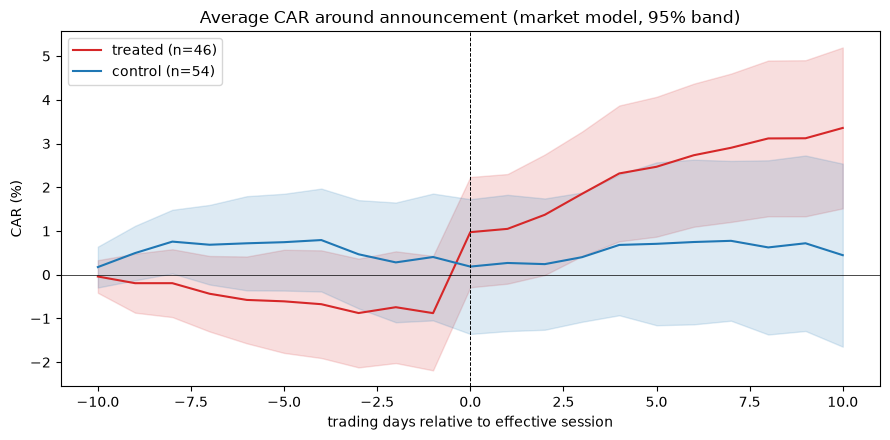

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4.5))
for name, color in (("treated", "tab:red"), ("control", "tab:blue")):
    m, ci, n = summary[name]
    ax.plot(rel_days, m * 100, color=color, label=f"{name} (n={n})")
    ax.fill_between(rel_days, (m - ci) * 100, (m + ci) * 100, color=color, alpha=0.15)
ax.axvline(0, color="k", lw=0.7, ls="--")
ax.axhline(0, color="k", lw=0.5)
ax.set_title("Average CAR around announcement (market model, 95% band)")
ax.set_xlabel("trading days relative to effective session")
ax.set_ylabel("CAR (%)")
ax.legend()
fig.tight_layout()

研究は注入したものを復元します。処置群は0日目におよそ +2% 跳ね、これは鋭くきわめて有意な
1日の差です。その後 +10日でおよそ +3.5% へドリフトします。対照群の CAR は帯の中でゼロ付近に
とどまるので、プラセボは正しく振る舞っています。

CAR[+10] の t 値が0日目のそれよりずっと弱いことに注目してください。21日ぶんの固有ノイズを、
およそ50件のイベントで累積すると検出力は急速に落ちます。実際のイベントスタディが標本サイズ
で生き死にするのは、まさにこのためです。

イベント前の CAR は両群とも平らで、揃え作業が先読みを持ち込まなかったことを裏づけます。
発表が価格に触れるのは効力発生セッション以降だけです。

## まとめ

- 実体化した取引カレンダーに対する `asof_join(..., 'forward', tolerance)` が、「発表以降で
  最初のセッション」の正しい原始操作です。祝日に依存せず、許容差を超えたぶんは静かなゴミ
  ではなく NULL を返します。許容差は生のマイクロ秒で、`timestamp[us, UTC]` の時刻列に
  合わせます。
- `asof_join(...)` はほかの関係と同じように組み合わせられます。1つの文が、前向きの揃えを
  `prices` への等結合につないで0日目の終値まで取りました。
- `events` を一級の h5i-db テーブルとして、時刻列を生の発表時刻にして持つと、カレンダーの
  対応付けがクエリの中に住みます。価格パネルを直したうえで走らせ直せば、自動的に解き直され
  ます。
- リターンと等ウェイトのマーケットファクターは SQL のウィンドウ1文から出ました。pandas に
  残るのはイベントごとの OLS のループだけです。
- 既知の効果を合成データに注入し、対照群には手を触れないでおくと、レシピがパイプライン自身の
  検査になります。

In [9]:
db.close()